In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
base_path = '../../data/modelling/'

X_train = pd.read_parquet(base_path + 'X_train.parquet')
X_test = pd.read_parquet(base_path + 'X_test.parquet')
y_train = pd.read_parquet(base_path + 'y_train.parquet')
y_test = pd.read_parquet(base_path + 'y_test.parquet')

In [3]:
y_train = np.ravel(y_train)
y_test = np.ravel(y_test)

In [4]:
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3076
[LightGBM] [Info] Number of data points in the train set: 8524, number of used features: 35
[LightGBM] [Info] Start training from score 13.326602


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [5]:
y_pred = model.predict(X_test)

In [6]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

MAE: 0.17989192697738207
RMSE: 0.25420554093684616
R2: 0.8306590604884684


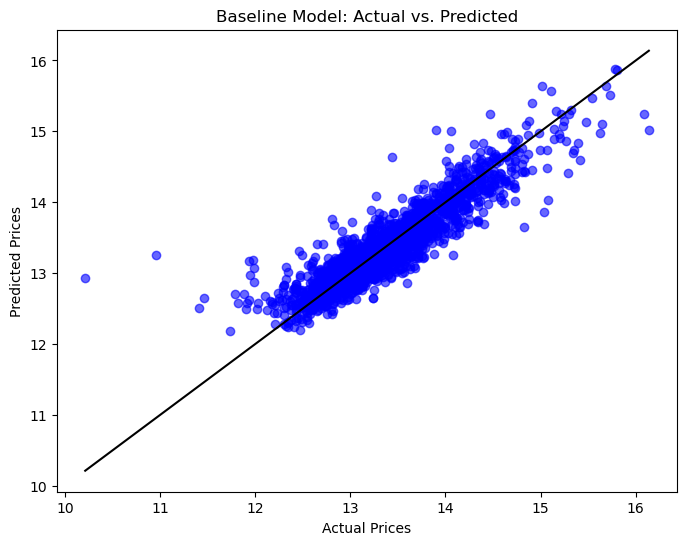

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Baseline Model: Actual vs. Predicted')
plt.show()

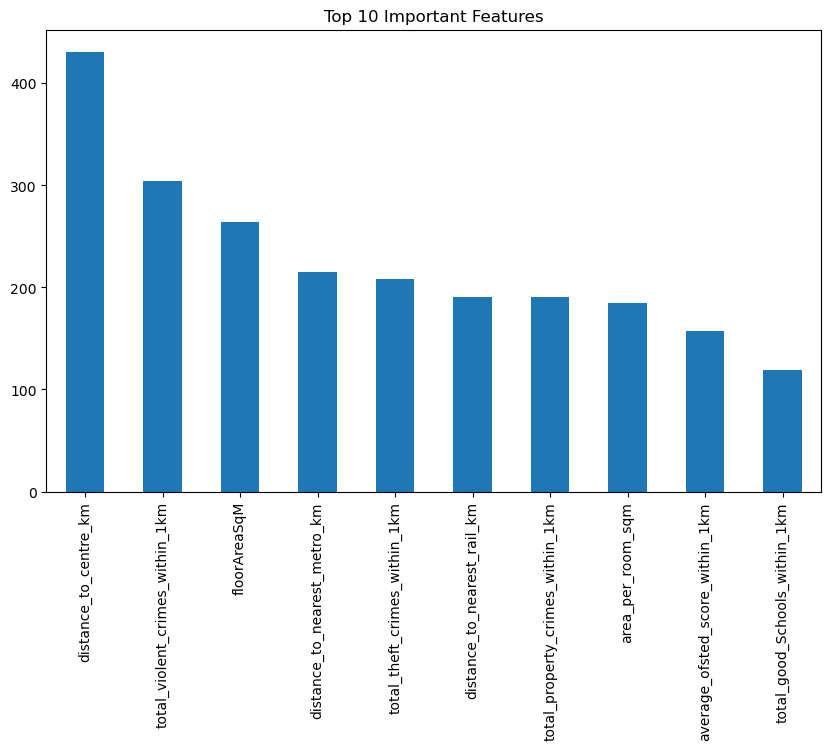

In [8]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

In [9]:
model_tuned = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    min_child_samples=10,
    colsample_bytree=0.8,
    random_state=42
)

model_tuned.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3078
[LightGBM] [Info] Number of data points in the train set: 8524, number of used features: 36
[LightGBM] [Info] Start training from score 13.326602


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


In [10]:
y_pred_tuned = model_tuned.predict(X_test)

In [11]:
mae_base = mean_absolute_error(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_base = r2_score(y_test, y_pred)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print('=== Baseline Model ===')
print('MAE:', mae_base)
print('RMSE:', rmse_base)
print('R2:', r2_base)

print('=== Tuned Model ===')
print('MAE:', mae_tuned)
print('RMSE:', rmse_tuned)
print('R2:', r2_tuned)

=== Baseline Model ===
MAE: 0.17989192697738207
RMSE: 0.25420554093684616
R2: 0.8306590604884684
=== Tuned Model ===
MAE: 0.17381416882306716
RMSE: 0.24679497888445223
R2: 0.8403883530804744


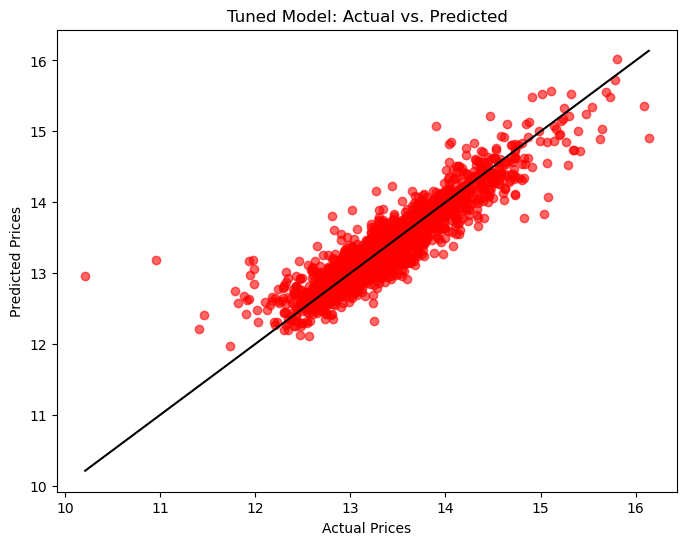

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tuned, alpha=0.6, color='red')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Tuned Model: Actual vs. Predicted')
plt.show()

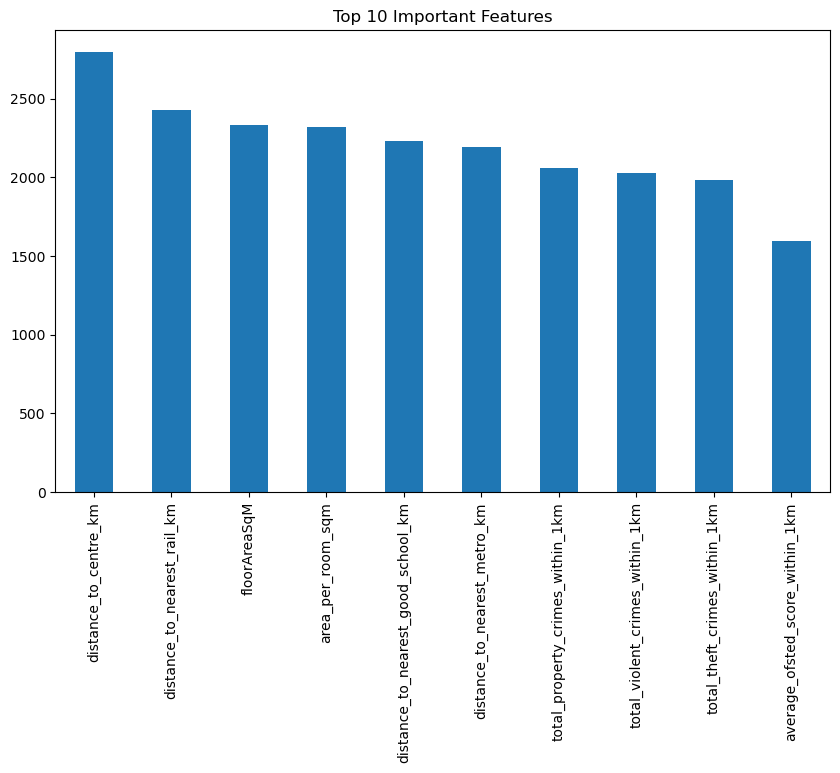

In [13]:
importance = pd.Series(model_tuned.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()